In [1]:
import os
import zipfile
import kagglehub
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
base_path = kagglehub.competition_download('dogs-vs-cats')
print(f"Downloaded zip file at: {base_path}")

train_zip=os.path.join(base_path,'train.zip')
test_zip=os.path.join(base_path,'test1.zip')

print("Unzipping...")

os.makedirs('data', exist_ok=True)

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('data')

with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall('data')

print("Done")

100%|██████████| 812M/812M [00:05<00:00, 154MB/s]

Extracting files...


Downloaded zip file at: /root/.cache/kagglehub/competitions/dogs-vs-cats
Unzipping...
Done


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [3]:
from torchvision import datasets,models,transforms
from torch.utils.data import DataLoader, Dataset,ConcatDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, copy, random
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
lr =1e-3
batch_size=64
epochs = 15
dropout_rate=0.4
num_workers=2


In [5]:
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(1234)
if device == 'cuda':
    torch.cuda.manual_seed_all(1234)

Device: cuda


In [6]:
# Load train and test data
train_dir = 'data/train'
test_dir = 'data/test1'
import glob

train_list = glob.glob(os.path.join(train_dir,'*.jpg'))
test_list = glob.glob(os.path.join(test_dir, '*.jpg'))

print(f"Train data: {len(train_list)}")
print(f"Test data: {len(test_list)}")

Train data: 25000
Test data: 12500


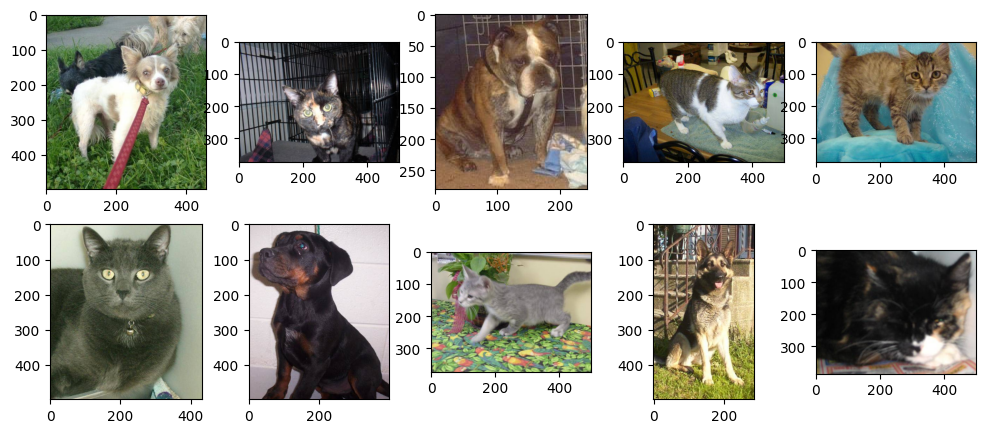

In [7]:
random_idx = np.random.randint(0,len(train_list),size=10)

fig = plt.figure(figsize=(12,5))
for i, idx in enumerate(random_idx, start=1):
    ax = fig.add_subplot(2,5,i)
    img = Image.open(train_list[idx])
    plt.imshow(img)
    ax.axis=('off')

plt.show()

In [ ]:
train_list[0].split('/')[-1].split('.')[0]

'cat'

In [8]:
normalize=transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])

train_transforms =transforms.Compose([
    transforms.Resize((256,256)), # zoom a bit first
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), # then crop randomly to 224, adjust scale to be less aggressive (lower bound =0.7 of the initial area instead of default 0.08)
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize
])


# remember to remove the crop & flip part, only use challenges to train, test data must be original
val_transforms  =transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])


# same as the above
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])




In [9]:
class CatDogDataset(torch.utils.data.Dataset):
    def __init__(self,file_list,transform = None):
        self.file_list=file_list
        self.transform=transform

    def __len__(self):
        self.filelength =len(self.file_list)
        return self.filelength

    def __getitem__(self,idx):
        img_path =self.file_list[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label=1
        elif label == 'cat':
            label=0

        return img,label


In [10]:
train_list,val_list = train_test_split(train_list , test_size =0.2, random_state=1234)

In [11]:
train_data = CatDogDataset(train_list,transform=train_transforms)
test_data = CatDogDataset(test_list,transform=test_transforms)
val_data = CatDogDataset(val_list,transform=val_transforms)



In [12]:
train_loader = torch.utils.data.DataLoader(dataset = train_data, batch_size = batch_size,shuffle = True, num_workers=num_workers, pin_memory=True)
test_loader = torch.utils.data.DataLoader(dataset = test_data, batch_size = batch_size,shuffle = False, num_workers=num_workers, pin_memory=True)
val_loader = torch.utils.data.DataLoader(dataset = val_data, batch_size = batch_size,shuffle = False, num_workers=num_workers, pin_memory=True)

In [ ]:
print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}, test batches: {len(test_loader)}")


train batches: 313, val batches: 79, test batches: 196


In [13]:
train_data[0][0].shape

torch.Size([3, 224, 224])

In [18]:
class Cnn(nn.Module):
  def __init__(self, dropout_rate=0.4):
    super().__init__()
    self.block1=self._conv_block(3,32)
    self.block2=self._conv_block(32,64)
    self.block3=self._conv_block(64,128)
    self.block4=self._conv_block(128,256)

    self.gap=nn.AdaptiveAvgPool2d(1)

    self.fc1=nn.Linear(256,128)
    self.dropout=nn.Dropout(dropout_rate)
    self.fc2=nn.Linear(128,2)
  @staticmethod
  def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )
  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.gap(x)
    x = x.flatten(1)
    x=F.relu(self.fc1(x))
    x=self.dropout(x)
    x=self.fc2(x)
    return x


In [15]:
model = Cnn(dropout_rate=dropout_rate).to(device)
optimizer = optim.Adam(params = model.parameters(),lr =lr)
criterion = nn.CrossEntropyLoss()

scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")
print(model)

Total trainable parameters: 422,530
Cnn(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 2

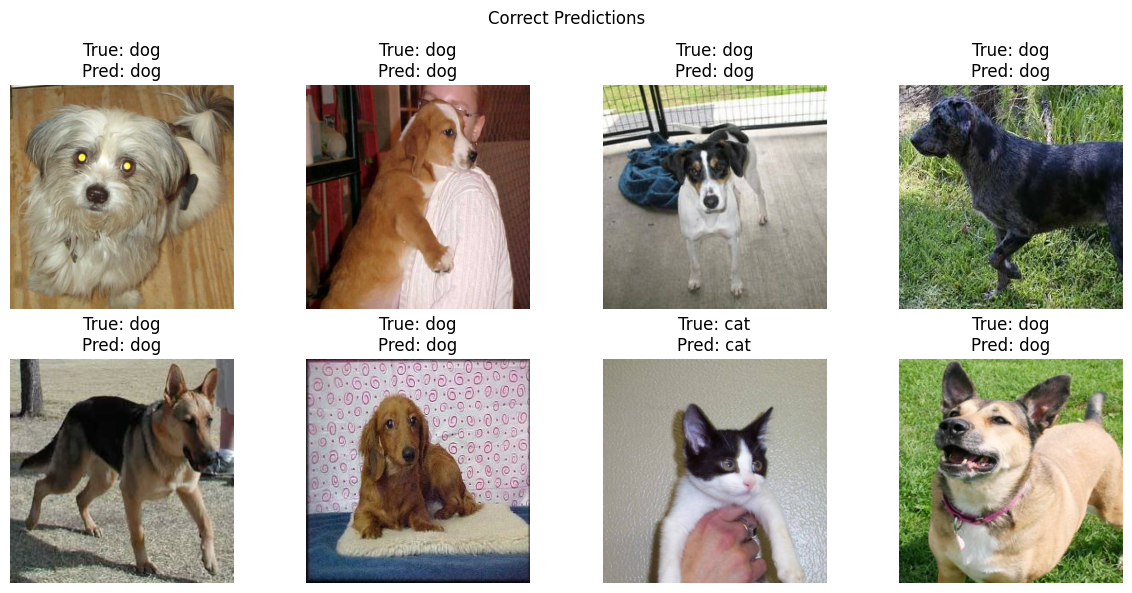

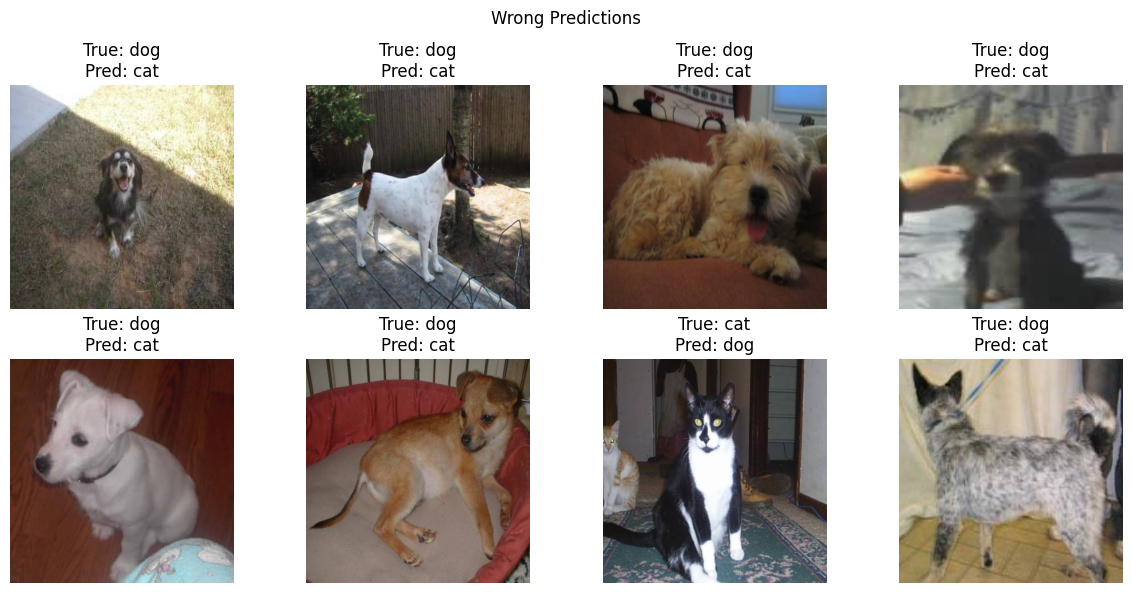

In [23]:
def show_examples(examples, title, n=8):
    n = min(n, len(examples))
    plt.figure(figsize=(12, 6))

    for i in range(n):
        img, true, pred = examples[i]

        # only use this if your images were normalized by ImageNet mean/std
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = img * std + mean
        img = img.clamp(0, 1)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(correct, "Correct Predictions")
show_examples(wrong, "Wrong Predictions")

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_state   = None

for epoch in range(epochs):
    # -------- Train --------
    model.train()
    epoch_loss, epoch_acc = 0.0, 0.0
    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() / len(train_loader)                            # .item() detaches
        epoch_acc  += (output.argmax(1) == label).float().mean().item() / len(train_loader)

    # -------- Validate --------
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for data, label in val_loader:
            data, label = data.to(device), label.to(device)
            output = model(data)
            loss = criterion(output, label)
            val_loss += loss.item() / len(val_loader)
            val_acc  += (output.argmax(1) == label).float().mean().item() / len(val_loader)

    # -------- Bookkeeping --------
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        marker = "  <-- best"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"train loss {epoch_loss:.4f} acc {epoch_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"lr {current_lr:.1e}{marker}")

# Restore the best weights
model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch  1/15 | train loss 0.6285 acc 0.6450 | val loss 0.5839 acc 0.6917 | lr 1.0e-03  <-- best
Epoch  2/15 | train loss 0.5633 acc 0.7146 | val loss 0.6269 acc 0.6766 | lr 1.0e-03
Epoch  3/15 | train loss 0.5270 acc 0.7437 | val loss 0.5027 acc 0.7627 | lr 1.0e-03  <-- best
Epoch  4/15 | train loss 0.5103 acc 0.7539 | val loss 1.1230 acc 0.5259 | lr 1.0e-03
Epoch  5/15 | train loss 0.4767 acc 0.7768 | val loss 0.4892 acc 0.7688 | lr 1.0e-03  <-- best
Epoch  6/15 | train loss 0.4594 acc 0.7903 | val loss 0.4881 acc 0.7684 | lr 1.0e-03
Epoch  7/15 | train loss 0.4226 acc 0.8136 | val loss 0.3944 acc 0.8289 | lr 1.0e-03  <-- best
Epoch  8/15 | train loss 0.4053 acc 0.8199 | val loss 0.8282 acc 0.6709 | lr 1.0e-03
Epoch  9/15 | train loss 0.3761 acc 0.8365 | val loss 0.3466 acc 0.8451 | lr 1.0e-03  <-- best
Epoch 10/15 | train loss 0.3553 acc 0.8457 | val loss 0.3376 acc 0.8550 | lr 1.0e-03  <-- best
Epoch 11/15 | train loss 0.3372 acc 0.8561 | val loss 0.3125 acc 0.8606 | lr 1.0e-03  <-- 

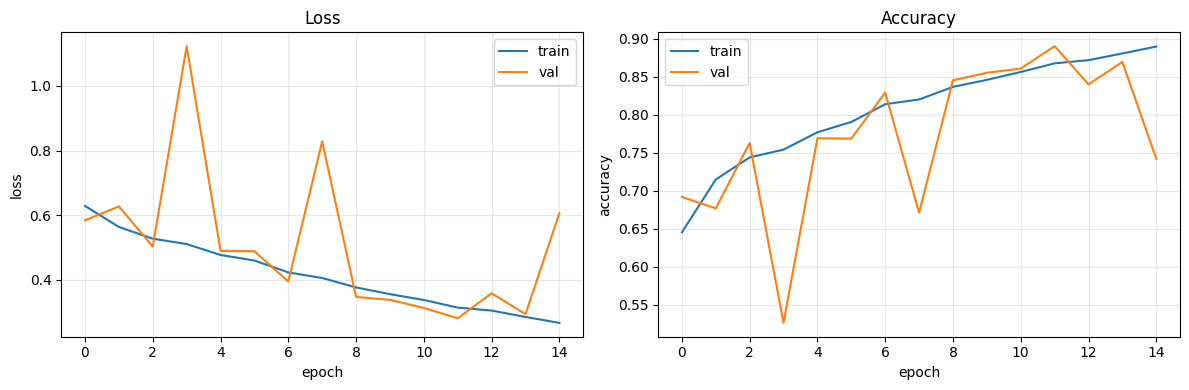

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for data, label in val_loader:
        data = data.to(device)
        preds = model(data).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(label.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:")
print("           pred_cat  pred_dog")
print(f"true_cat   {cm[0,0]:>8}  {cm[0,1]:>8}")
print(f"true_dog   {cm[1,0]:>8}  {cm[1,1]:>8}")
print()
print(classification_report(all_labels, all_preds, target_names=['cat', 'dog']))

Confusion matrix:
           pred_cat  pred_dog
true_cat       2237       291
true_dog        265      2207

              precision    recall  f1-score   support

         cat       0.89      0.88      0.89      2528
         dog       0.88      0.89      0.89      2472

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



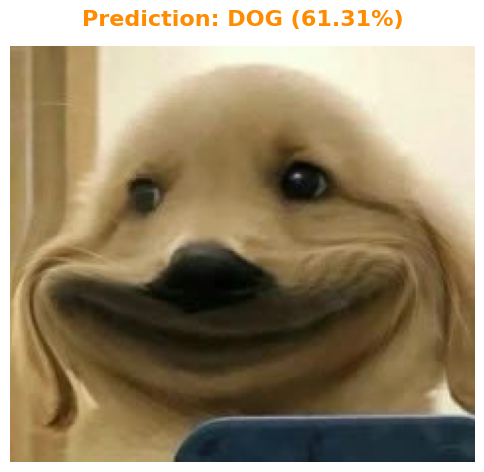

In [ ]:
def predict_and_show_image(image_path, model, device):
    model.eval()
    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize,
    ])

    img_original = Image.open(image_path).convert('RGB')
    img_tensor   = infer_transform(img_original).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs  = F.softmax(output, dim=1)[0]
        cat_prob, dog_prob = probs[0].item() * 100, probs[1].item() * 100

    if dog_prob > cat_prob:
        label, confidence = "DOG", dog_prob
    else:
        label, confidence = "CAT", cat_prob

    plt.figure(figsize=(6, 6))
    plt.imshow(img_original)
    color = 'green' if confidence > 80.0 else 'darkorange'
    plt.title(f"Prediction: {label} ({confidence:.2f}%)",
              fontsize=16, fontweight='bold', color=color, pad=15)
    plt.axis('off'); plt.show()

# Example:
# predict_and_show_image("thong.jpg", model, device)
